
=== Optimizing for σ = (2, 3, 1) ===



Best σ = (2, 3, 1),  final MSE = 3.757030e-04
Saved → reconstructed_algos.csv


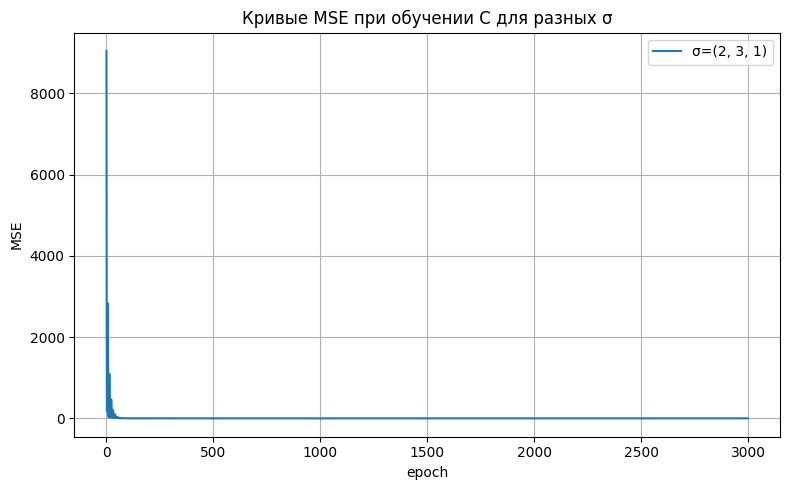

In [35]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
KaiNet — восстановление фильтра C с помощью PyTorch-градиентного спуска.
Author: <ваше_имя>
"""
from pathlib import Path
from itertools import permutations
import numpy as np
from scipy.signal import convolve2d
import torch
from torch.nn.functional import conv2d
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.manual_seed(42)

# ---------- 0. Данные ----------
A, B = np.loadtxt('best_pictures/algos.csv', delimiter=',').reshape(2, 3, 3)
A_t = torch.tensor(A, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # 1×1×3×3
B_t = torch.tensor(B, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

def load_pairs():
    xs, ys = [], []
    for p in sorted(Path('best_pictures/').glob('*.png')):
        # ---------- вход ----------
        x = plt.imread(p)
        if x.ndim == 3:                 # RGB / RGBA
            x = x[:, :, 0]              # первый канал
        if x.max() <= 1.0:              # PNG → 0-1
            x = x * 255.0
        xs.append(torch.tensor(x, dtype=torch.float32))

        # ---------- целевой выход ----------
        y = np.loadtxt(p.with_suffix('.txt'))
        ys.append(torch.tensor(y, dtype=torch.float32))
    return xs, ys

X_list, Y_list = load_pairs()
same_shape = (Y_list[0].shape == X_list[0].shape)
pad = 1 if same_shape else 0   # 3×3 kernel → pad=1 for 'same'

# ---------- 1. Подготовка батча ----------
X_batch = torch.stack([x.unsqueeze(0) for x in X_list])  # N×1×H×W
Y_batch = torch.stack([y.unsqueeze(0) for y in Y_list])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_batch = X_batch.to(device)
Y_batch = Y_batch.to(device)
A_t, B_t = A_t.to(device), B_t.to(device)

# ---------- 2. Градиентный цикл ----------
EPOCHS     = 3000
LR         = 1e-1
loss_curves = {}                      # σ → list[loss]

best_mse   = float('inf')
best_sigma = None
best_C     = None

for sigma in permutations((1, 2, 3)):
    if 3 not in sigma:
        continue
    if sigma != (2, 3, 1):
        continue
    print(f'\n=== Optimizing for σ = {sigma} ===')
    C = torch.zeros((1, 1, 3, 3), device=device, requires_grad=True)
    opt = torch.optim.Adam([C], lr=LR)
    curve = []

    for epoch in tqdm(range(1, EPOCHS + 1), leave=False):
        opt.zero_grad()
        Z = X_batch
        for idx in sigma:
            if idx == 1:
                Z = conv2d(Z, A_t, padding=pad)
            elif idx == 2:
                Z = conv2d(Z, B_t, padding=pad)
            else:                    # idx == 3  → учим
                Z = conv2d(Z, C,   padding=pad)

        loss = torch.mean((Z - Y_batch) ** 2)
        loss.backward()
        opt.step()

        curve.append(loss.item())

    # запомним кривую и результат
    loss_curves[sigma] = curve
    final_mse = curve[-1]

    if final_mse < best_mse:
        best_mse, best_sigma = final_mse, sigma
        best_C = C.detach().cpu().numpy()

print(f'\nBest σ = {best_sigma},  final MSE = {best_mse:.6e}')

# ─────────────────────────────── 3. Сохранение ────────────────────────────────
filters = {1: A, 2: B, 3: best_C.squeeze()}
out = np.vstack([filters[i].ravel() for i in best_sigma])
np.savetxt('reconstructed_algos.csv', out, delimiter=',', fmt='%.6f')
print('Saved → reconstructed_algos.csv')

# ─────────────────────────────── 4. График потерь ─────────────────────────────
plt.figure(figsize=(8,5))
for sigma, curve in loss_curves.items():
    plt.plot(curve, label=f"σ={sigma}")
plt.title("Кривые MSE при обучении C для разных σ")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()           # сохранится в файл, если установлен backend "Agg"

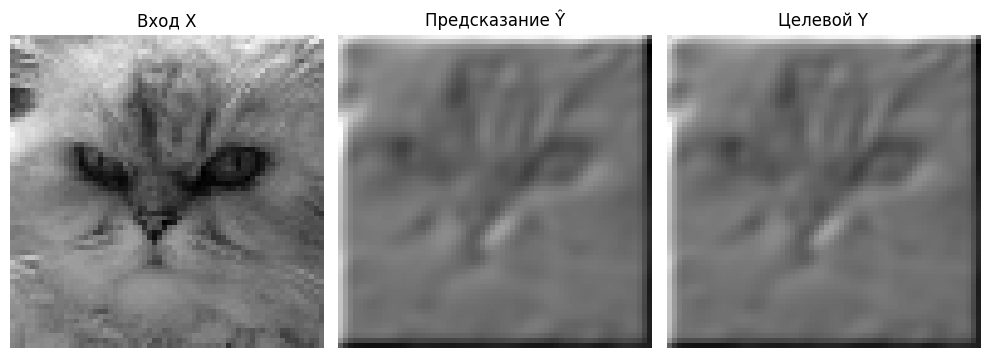

In [25]:
# ─────────────────── 6. Визуальное сравнение трёх картинок ────────────────
idx_demo = 0                                 # покажем первую пару
X_demo   = X_list[idx_demo].numpy()
Y_demo   = Y_list[idx_demo].numpy()

# --- применяем найденный конвейер ---
Z = torch.tensor(X_demo, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
for idx in best_sigma:
    kernel = torch.tensor(filters[idx], dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
    Z = conv2d(Z, kernel, padding=pad)
Z_pred = Z.squeeze().cpu().numpy()

# --- отображаем ---
plt.figure(figsize=(10,3.5))

plt.subplot(1,3,1)
plt.title("Вход X")
plt.imshow(X_demo, cmap='gray'), plt.axis('off')

plt.subplot(1,3,2)
plt.title("Предсказание Ŷ")
plt.imshow(Z_pred, cmap='gray'), plt.axis('off')

plt.subplot(1,3,3)
plt.title("Целевой Y")
plt.imshow(Y_demo, cmap='gray'), plt.axis('off')

plt.tight_layout()
plt.show()
# plt.savefig("comparison.png")